In [1]:
import os
#os.environ["TRITON_INTERPRET"] = "1"
#os.environ["TRITON_PRINT_AUTOTUNING"] = "1"
import torch
import torch.nn as nn
import torch.nn.functional as F
import triton
import triton.language as tl

torch.manual_seed(0)
device = torch.device("cuda:4")
torch.cuda.set_device(device)

In [2]:
@triton.jit
def layernorm_forward(x_ptr, y_ptr, mean_ptr, std_ptr, weight_ptr, bias_ptr, eps, embed_dim, BLOCK_SIZE: tl.constexpr):
    pid_0 = tl.program_id(0)

    xy_start = pid_0 * embed_dim
    xy_offsets = xy_start + tl.arange(0, BLOCK_SIZE)
    xy_mask = tl.arange(0, BLOCK_SIZE) < embed_dim

    wb_offsets = tl.arange(0, BLOCK_SIZE)
    wb_mask = wb_offsets < embed_dim

    x = tl.load(x_ptr + xy_offsets, mask=xy_mask).to(tl.float32)
    weight = tl.load(weight_ptr + wb_offsets, mask=wb_mask).to(tl.float32)
    bias = tl.load(bias_ptr + wb_offsets, mask=wb_mask).to(tl.float32)

    x_mean = tl.sum(x) / embed_dim
    tl.store(mean_ptr + pid_0, x_mean)
    x2_mean = tl.sum(x * x) / embed_dim
    x_rstd = 1.0 / tl.sqrt(x2_mean - x_mean * x_mean + eps)
    tl.store(std_ptr + pid_0, x_rstd)

    x_norm = (x - x_mean) * x_rstd
    y = x_norm * weight + bias

    tl.store(y_ptr + xy_offsets, y, mask=xy_mask)

This kernel performs backward pass by accumulating dw and db across multiple batches for each SM. It avoids locks but increases SRAM usage by keeping accumulator variables throughout the loop.

In [3]:
@triton.jit
def layernorm_backward(dy_ptr, dx_ptr, dw_ptr, db_ptr, x_ptr, mean_ptr, std_ptr, weight_ptr, batch_size, embed_dim, NUM_SM: tl.constexpr, BLOCK_SIZE: tl.constexpr):
    pid_0 = tl.program_id(0)

    block_range = tl.arange(0, BLOCK_SIZE)
    mask = block_range < embed_dim
    weight = tl.load(weight_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
    dw = tl.zeros((BLOCK_SIZE,), dtype=tl.float32)
    db = tl.zeros((BLOCK_SIZE,), dtype=tl.float32)

    xydwb_start = pid_0 * embed_dim
    x_ptr += xydwb_start
    dy_ptr += xydwb_start
    dx_ptr += xydwb_start
    dw_ptr += xydwb_start
    db_ptr += xydwb_start
    
    for batch in tl.range(pid_0, batch_size, NUM_SM, num_stages=0):
        x = tl.load(x_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
        dy = tl.load(dy_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
        x_mean = tl.load(mean_ptr + batch)
        x_rstd = tl.load(std_ptr + batch)
        
        x_norm = (x - x_mean) * x_rstd
        x_norm = tl.where(mask, x_norm, 0.0)
        dy_times_weight = dy * weight
        term1 = tl.sum(x_norm * dy_times_weight) / embed_dim
        term2 = tl.sum(dy_times_weight) / embed_dim
        dx = (dy_times_weight - (term1 * x_norm + term2)) * x_rstd
        tl.store(dx_ptr + block_range, dx, mask=mask)
    
        dw += dy * x_norm
        db += dy
        
        x_ptr += NUM_SM * embed_dim
        dy_ptr += NUM_SM * embed_dim
        dx_ptr += NUM_SM * embed_dim
    
    
    tl.store(dw_ptr + block_range, dw, mask=mask)
    tl.store(db_ptr + block_range, db, mask=mask)

This kernel uses locks and spreads them out across NUM_SM values to minimize time programs wait to acquire locks.

In [4]:
@triton.jit
def layernorm_backward_locks(dy_ptr, dx_ptr, dw_ptr, db_ptr, x_ptr, mean_ptr, std_ptr, weight_ptr, locks_ptr, batch_size, embed_dim, NUM_SM: tl.constexpr, BLOCK_SIZE: tl.constexpr):
    pid_0 = tl.program_id(0)
    smid_0 = pid_0 % NUM_SM

    block_range = tl.arange(0, BLOCK_SIZE)
    mask = block_range < embed_dim
    dwb_start = smid_0 * embed_dim
    dw_ptr += dwb_start
    db_ptr += dwb_start
    lock_ptr = locks_ptr + smid_0
    xy_start = pid_0 * embed_dim

    x_ptr += xy_start
    dy_ptr += xy_start
    dx_ptr += xy_start
    x = tl.load(x_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
    dy = tl.load(dy_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
    weight = tl.load(weight_ptr + block_range, mask=mask, other=0.0).to(tl.float32)
    x_mean = tl.load(mean_ptr + pid_0)
    x_rstd = tl.load(std_ptr + pid_0)
    
    x_norm = (x - x_mean) * x_rstd
    x_norm = tl.where(mask, x_norm, 0.0)
    dy_times_weight = dy * weight
    term1 = tl.sum(x_norm * dy_times_weight) / embed_dim
    term2 = tl.sum(dy_times_weight) / embed_dim
    dx = (dy_times_weight - (term1 * x_norm + term2)) * x_rstd
    tl.store(dx_ptr + block_range, dx, mask=mask)

    dw = dy * x_norm
    db = dy

    while tl.atomic_cas(lock_ptr, 0, 1) == 1:
        pass

    dw_total = tl.load(dw_ptr + block_range, mask=mask)
    db_total = tl.load(db_ptr + block_range, mask=mask)
    dw_total += dw
    db_total += db
    tl.store(dw_ptr + block_range, dw_total, mask=mask)
    tl.store(db_ptr + block_range, db_total, mask=mask)

    tl.atomic_xchg(lock_ptr, 0)

    

This kernel uses locks like before but this time iterates through columns in two loops. First loop computes constants needed for backward pass and second loop uses them to calculate and store gradients. The kernel ends up loading x, dy and weight twice so works best if we cannot fit the whole batch/row in registers.

In [5]:
@triton.jit
def layernorm_backward_locks_splitcols(dy_ptr, dx_ptr, dw_ptr, db_ptr, x_ptr, mean_ptr, std_ptr, weight_ptr, locks_ptr, batch_size, embed_dim, NUM_SM: tl.constexpr, BLOCK_SIZE: tl.constexpr, num_stages: tl.constexpr):
    pid_0 = tl.program_id(0)
    smid_0 = pid_0 % NUM_SM

    block_range = tl.arange(0, BLOCK_SIZE)
    mask = block_range < embed_dim
    dwb_start = smid_0 * embed_dim
    dw_ptr += dwb_start
    db_ptr += dwb_start

    xy_start = pid_0 * embed_dim
    x_ptr += xy_start
    dy_ptr += xy_start
    dx_ptr += xy_start
    lock_ptr = locks_ptr + smid_0

    x_mean = tl.load(mean_ptr + pid_0)
    x_rstd = tl.load(std_ptr + pid_0)
    c1 = 0.0
    c2 = 0.0

    for j in tl.range(0, embed_dim, BLOCK_SIZE, num_stages=num_stages):
        mask = j + block_range < embed_dim

        x = tl.load(x_ptr + j + block_range, mask=mask).to(tl.float32)
        dy = tl.load(dy_ptr + j + block_range, mask=mask).to(tl.float32)
        weight = tl.load(weight_ptr + j + block_range, mask=mask).to(tl.float32)
        
        x_norm = (x - x_mean) * x_rstd
        x_norm = tl.where(mask, x_norm, 0.0)
        dy_times_weight = dy * weight
        c1 += tl.sum(x_norm * dy_times_weight)
        c2 += tl.sum(dy_times_weight)

        dw = dy * x_norm
        db = dy

        while tl.atomic_cas(lock_ptr, 0, 1) == 1:
            pass

        dw_total = tl.load(dw_ptr + block_range, mask=mask)
        db_total = tl.load(db_ptr + block_range, mask=mask)
        dw_total += dw
        db_total += db
        tl.store(dw_ptr + block_range, dw_total, mask=mask)
        tl.store(db_ptr + block_range, db_total, mask=mask)
    
        tl.atomic_xchg(lock_ptr, 0)

        dw_ptr += BLOCK_SIZE
        db_ptr += BLOCK_SIZE


    c1 /= embed_dim
    c2 /= embed_dim
    
    for j in tl.range(0, embed_dim, BLOCK_SIZE, num_stages=num_stages):
        mask = j + block_range < embed_dim

        x = tl.load(x_ptr + j + block_range, mask=mask).to(tl.float32)
        dy = tl.load(dy_ptr + j + block_range, mask=mask).to(tl.float32)
        weight = tl.load(weight_ptr + j + block_range, mask=mask).to(tl.float32)
        
        x_norm = (x - x_mean) * x_rstd
        x_norm = tl.where(mask, x_norm, 0.0)
        dy_times_weight = dy * weight
        dx = (dy_times_weight - (c1 * x_norm + c2)) * x_rstd
        tl.store(dx_ptr + j + block_range, dx, mask=mask)

In [6]:
@triton.jit
def layernorm_backward_reduce(dw_partial_ptr, db_partial_ptr, dw_ptr, db_ptr, batch_size, embed_dim, BATCH_BLOCK_SIZE: tl.constexpr, EMBED_BLOCK_SIZE: tl.constexpr):
    pid_0 = tl.program_id(0)
    batch_block_range = tl.arange(0, BATCH_BLOCK_SIZE)
    embed_block_range = tl.arange(0, EMBED_BLOCK_SIZE)
    dwb_start = pid_0 * EMBED_BLOCK_SIZE
    dwb_offsets = dwb_start + embed_block_range
    dwb_mask = embed_block_range < embed_dim
    #dw = tl.zeros((BATCH_BLOCK_SIZE, EMBED_BLOCK_SIZE), dtype=tl.float32)
    #db = tl.zeros((BATCH_BLOCK_SIZE, EMBED_BLOCK_SIZE), dtype=tl.float32)
    #dwb_partial_start = pid_0 * embed_dim
    #dwb_partial_offsets = dwb_partial_start + block_range
    #dwb_partial_start = pid_0 * EMBED_BLOCK_SIZE
    dwb_partial_offsets = dwb_start + (batch_block_range[:, None] * embed_dim + embed_block_range[None, :])

    #for i in tl.range(0, batch_size, BATCH_BLOCK_SIZE, num_stages=0):
    #dwb_partial_start = i * embed_dim + pid_0 * EMBED_BLOCK_SIZE
    #dwb_partial_offsets = dwb_partial_start + (tl.arange(0, BATCH_BLOCK_SIZE)[:, None] * embed_dim + tl.arange(0, EMBED_BLOCK_SIZE)[None, :])
    dwb_partial_mask = (batch_block_range[:, None] < batch_size) & (pid_0 + embed_block_range[None, :] < embed_dim)
    dw_partial = tl.load(dw_partial_ptr + dwb_partial_offsets, mask=dwb_partial_mask, other=0.0)
    db_partial = tl.load(db_partial_ptr + dwb_partial_offsets, mask=dwb_partial_mask, other=0.0)
    dw = tl.sum(dw_partial, 0)
    db = tl.sum(db_partial, 0)
    #dwb_partial_offsets += BATCH_BLOCK_SIZE * embed_dim

    #dw = tl.sum(dw, 0)
    #db = tl.sum(db, 0)

    tl.store(dw_ptr + dwb_offsets, dw, mask=dwb_mask)
    tl.store(db_ptr + dwb_offsets, db, mask=dwb_mask)
        
    

In [7]:
class myLayerNorm(torch.autograd.Function):
    
    @staticmethod
    def forward(ctx, x, weight, bias, eps, use_locks=0):
        batch_size = x.shape[0]
        embed_dim = x.shape[1]
        y = torch.empty_like(x)
        mean = torch.empty((batch_size,), device=device, dtype=torch.float32)
        std = torch.empty((batch_size,), device=device, dtype=torch.float32)
        BLOCK_SIZE = triton.next_power_of_2(embed_dim)
        grid = (batch_size,)
        kernel = layernorm_forward[grid](x, y, mean, std, weight, bias, eps, embed_dim, BLOCK_SIZE)
        #print(mean.dtype)
        ctx.save_for_backward(x, mean, std, weight)
        ctx.BLOCK_SIZE = BLOCK_SIZE
        ctx.use_locks = use_locks
        return y


    @staticmethod
    def backward(ctx, dy):
        x, mean, std, weight = ctx.saved_tensors
        batch_size = x.shape[0]
        embed_dim = x.shape[1]
        dx = torch.empty_like(dy)
        dw = torch.zeros((embed_dim,), device=device, dtype=torch.float16)
        db = torch.zeros((embed_dim,), device=device, dtype=torch.float16)
        BLOCK_SIZE = ctx.BLOCK_SIZE
        use_locks = ctx.use_locks
        num_warps = 8
        NUM_SM = 108
        dw_partial = torch.zeros((NUM_SM, embed_dim), device=device, dtype=torch.float32)
        db_partial = torch.zeros((NUM_SM, embed_dim), device=device, dtype=torch.float32)
        BATCH_BLOCK_SIZE = triton.next_power_of_2(NUM_SM)
        EMBED_BLOCK_SIZE = 32
        if use_locks == 0:
            grid = (NUM_SM,)
            kernel = layernorm_backward[grid](dy, dx, dw_partial, db_partial, x, mean, std, weight, batch_size, embed_dim, NUM_SM, BLOCK_SIZE, num_warps=num_warps)
        elif use_locks == 1:
            locks = torch.zeros((NUM_SM,), device=device, dtype=torch.int32)
            grid = (batch_size,)
            kernel = layernorm_backward_locks[grid](dy, dx, dw_partial, db_partial, x, mean, std, weight, locks, batch_size, embed_dim, NUM_SM, BLOCK_SIZE, num_warps=num_warps)
        elif use_locks == 2:
            BLOCK_SIZE = min(BLOCK_SIZE, 4096)
            locks = torch.zeros((NUM_SM,), device=device, dtype=torch.int32)
            grid = (batch_size,)
            kernel = layernorm_backward_locks_splitcols[grid](dy, dx, dw_partial, db_partial, x, mean, std, weight, locks, batch_size, embed_dim, NUM_SM, BLOCK_SIZE, num_stages=2, num_warps=num_warps)
        #print(kernel.asm['ptx'])
        grid2 = lambda args: (triton.cdiv(embed_dim, args['EMBED_BLOCK_SIZE']),)
        kernel2 = layernorm_backward_reduce[grid2](dw_partial, db_partial, dw, db, NUM_SM, embed_dim, BATCH_BLOCK_SIZE, EMBED_BLOCK_SIZE, num_warps=4)
        return dx, dw, db, None, None

apply_layernorm = myLayerNorm.apply


In [8]:
batch_size = 1024
embed_dim = 3000
eps = 1e-5
use_locks = 0

x = -2.3 + 0.5 * torch.randn((batch_size, embed_dim), device=device, dtype=torch.float16) #, requires_grad=True)
#x = torch.randn((batch_size, embed_dim), device=device, dtype=torch.float16)
x.requires_grad = True
weight = torch.rand((embed_dim,), device=device, dtype=torch.float16, requires_grad=True)
bias = torch.rand((embed_dim,), device=device, dtype=torch.float16, requires_grad=True)

output_torch = F.layer_norm(x, (embed_dim,), weight, bias) 
output_triton = apply_layernorm(x, weight, bias, eps, use_locks) 
print(output_torch.size())
print(output_triton.size())
print(output_torch.dtype)
print(output_triton.dtype)

print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')
print(f'The mean difference between torch and triton is '
      f'{torch.mean(torch.abs(output_torch - output_triton))}')
print(output_torch == output_triton)
#print(q[0, 0, 0])
print(output_torch[0])
print(output_triton[0])
#print(output_torch[0, 2] == output_triton[0, 2])

torch.Size([1024, 3000])
torch.Size([1024, 3000])
torch.float16
torch.float16
The maximum difference between torch and triton is 0.001953125
The mean difference between torch and triton is 4.76837158203125e-07
tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:4')
tensor([-0.3948,  0.5156,  0.8687,  ...,  0.9551,  0.7222,  0.2240],
       device='cuda:4', dtype=torch.float16, grad_fn=<SelectBackward0>)
tensor([-0.3948,  0.5156,  0.8687,  ...,  0.9551,  0.7222,  0.2240],
       device='cuda:4', dtype=torch.float16, grad_fn=<SelectBackward0>)


In [9]:
dy = 0.1 * torch.randn((batch_size, embed_dim), device=device, dtype=torch.float16)
output_torch.backward(dy, retain_graph=True)
dx_torch, dw_torch, db_torch = x.grad.clone(), weight.grad.clone(), bias.grad.clone()
x.grad, weight.grad, bias.grad = None, None, None
output_triton.backward(dy, retain_graph=True)
dx_triton, dw_triton, db_triton = x.grad.clone(), weight.grad.clone(), bias.grad.clone()
x.grad, weight.grad, bias.grad = None, None, None

print(dx_torch.size())
print(dx_triton.size())
print(dx_torch.dtype)
print(dx_triton.dtype)

print(f'The maximum dx difference between torch and triton is '
      f'{torch.max(torch.abs(dx_torch - dx_triton))}')
print(f'The mean dx difference between torch and triton is '
      f'{torch.mean(torch.abs(dx_torch - dx_triton))}')
print(dx_torch == dx_triton)
print(dx_torch[0])
print(dx_triton[0])
#print(output_torch[0, 2] == output_triton[0, 2])
print()

print(dw_torch.size())
print(dw_triton.size())
print(dw_torch.dtype)
print(dw_triton.dtype)
print(f'The maximum dw difference between torch and triton is '
      f'{torch.max(torch.abs(dw_torch - dw_triton))}')
print(f'The mean dw difference between torch and triton is '
      f'{torch.mean(torch.abs(dw_torch - dw_triton))}')
print(dw_torch == dw_triton)
print(dw_torch)
print(dw_triton)
#print(output_torch[0, 2] == output_triton[0, 2])
print()

print(db_torch.size())
print(db_triton.size())
print(db_torch.dtype)
print(db_triton.dtype)
print(f'The maximum db difference between torch and triton is '
      f'{torch.max(torch.abs(db_torch - db_triton))}')
print(f'The mean db difference between torch and triton is '
      f'{torch.mean(torch.abs(db_torch - db_triton))}')
print(db_torch == db_triton)
print(db_torch)
print(db_triton)

torch.Size([1024, 3000])
torch.Size([1024, 3000])
torch.float16
torch.float16
The maximum dx difference between torch and triton is 0.00048828125
The mean dx difference between torch and triton is 1.1920928955078125e-07
tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:4')
tensor([-0.1437,  0.2634, -0.0034,  ...,  0.1448, -0.0101,  0.0537],
       device='cuda:4', dtype=torch.float16)
tensor([-0.1437,  0.2634, -0.0034,  ...,  0.1448, -0.0101,  0.0537],
       device='cuda:4', dtype=torch.float16)

torch.Size([3000])
torch.Size([3000])
torch.float16
torch.float16
The maximum dw difference between torch and triton is 0.00390625
The mean dw difference between torch and triton is 2.9206275939941406e-06
ten

In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        #x_vals=[2**i for i in range (9, 15, 1)],  # Different possible values for `x_name`.
        x_vals=[1024 * i for i in range(1, 25)],
        #x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['torch', 'triton_nolocks', 'triton_locks', 'triton_locks_splitcols'],  # Possible values for `line_arg`.
        line_names=['Torch', 'Triton no locks', 'Triton locks', 'Triton locks splitcols'],  # Label name for the lines.
        styles=[('green', '-'), ('blue', '-'), ('red', '-'), ('orange', '-')],  # Line styles.
        ylabel='Gb/s',  # Label name for the y-axis.
        plot_name='layernorm-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    batch_size = 4096
    embed_dim = size
    eps = 1e-5
    x = -2.3 + 0.5 * torch.randn((batch_size, embed_dim), device=device, dtype=torch.float16) #, requires_grad=True)
    x.requires_grad = True
    weight = torch.rand((embed_dim,), device=device, dtype=torch.float16, requires_grad=True)
    bias = torch.rand((embed_dim,), device=device, dtype=torch.float16, requires_grad=True)
    dy = 0.1 * torch.randn((batch_size, embed_dim), device=device, dtype=torch.float16)
    if provider == 'torch':
        y = F.layer_norm(x, (embed_dim,), weight, bias)
        ms = triton.testing.do_bench(lambda: y.backward(dy, retain_graph=True), grad_to_none=[x, weight, bias], rep=500)
    if provider == 'triton_nolocks':
        y = apply_layernorm(x, weight, bias, eps, 0)
        ms = triton.testing.do_bench(lambda: y.backward(dy, retain_graph=True), grad_to_none=[x, weight, bias], rep=500)
    if provider == 'triton_locks':
        y = apply_layernorm(x, weight, bias, eps, 1)
        ms = triton.testing.do_bench(lambda: y.backward(dy, retain_graph=True), grad_to_none=[x, weight, bias], rep=500)
    if provider == 'triton_locks_splitcols':
        y = apply_layernorm(x, weight, bias, eps, 2)
        ms = triton.testing.do_bench(lambda: y.backward(dy, retain_graph=True), grad_to_none=[x, weight, bias], rep=500)

    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


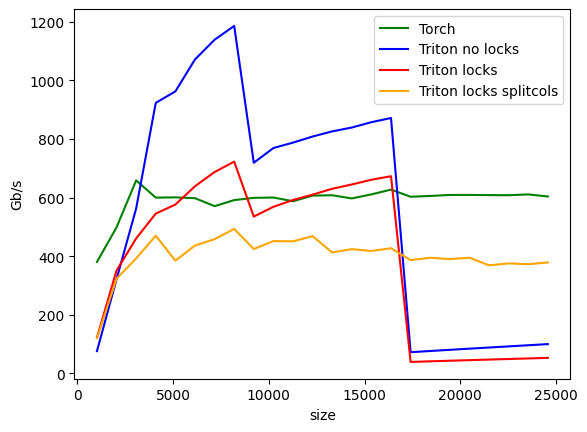

layernorm-performance:
       size       Torch  Triton no locks  Triton locks  Triton locks splitcols
0    1024.0  380.393802        76.121804    122.287421              120.239878
1    2048.0  498.427757       321.692841    351.284134              323.357439
2    3072.0  658.560896       562.868799    460.671990              392.336330
3    4096.0  599.915511       923.053527    545.435145              470.006363
4    5120.0  600.692730       962.247293    576.177758              384.926795
5    6144.0  597.967806      1071.175822    638.621745              436.455956
6    7168.0  570.707966      1138.407554    687.096651              458.119577
7    8192.0  591.394256      1185.581063    722.569703              493.109454
8    9216.0  599.080319       718.764236    535.244901              424.635862
9   10240.0  600.178292       769.071188    568.452863              451.409881
10  11264.0  587.535381       787.445215    591.719509              450.685186
11  12288.0  606.749335      

In [11]:
benchmark.run(print_data=True, show_plots=True)